# Modelos de Linguagem com LSTM

Este notebook introduz os **Modelos de Linguagem** (*Language Models*), uma das aplicações mais fundamentais e poderosas do processamento de linguagem natural. Exploraremos a teoria matemática por trás desses modelos e implementaremos uma versão prática usando **Long Short-Term Memory (LSTM)** networks com PyTorch.

## Fundamentos de Modelos de Linguagem

Um **modelo de linguagem** é um modelo probabilístico que atribui probabilidades a sequências de palavras. Formalmente, dado um vocabulário $V$ e uma sequência de palavras $w_1, w_2, \ldots, w_T$, um modelo de linguagem estima a probabilidade conjunta:

$$P(w_1, w_2, \ldots, w_T)$$

### Decomposição Autorregressiva

Pela regra da cadeia da probabilidade, podemos decompor essa probabilidade conjunta como:

$$P(w_1, w_2, \ldots, w_T) = \prod_{t=1}^{T} P(w_t | w_1, w_2, \ldots, w_{t-1})$$

Onde $P(w_t | w_1, \ldots, w_{t-1})$ é a **probabilidade condicional** da palavra $w_t$ dado todo o contexto anterior. Esta decomposição é chamada de **autorregressiva** porque cada palavra é modelada condicionalmente em relação às palavras anteriores.

### O Problema da Maldição da Dimensionalidade

Estimar $P(w_t | w_1, \ldots, w_{t-1})$ diretamente é impraticável, pois:
1. O número de possíveis contextos cresce exponencialmente com o comprimento
2. A maioria das sequências específicas nunca aparece nos dados de treino

### Aproximação Neural

Modelos neurais de linguagem resolvem este problema aprendendo uma função paramétrica $f_\theta$:

$$P(w_t | w_1, \ldots, w_{t-1}) \approx f_\theta(w_1, \ldots, w_{t-1})$$

Onde $\theta$ representa os parâmetros da rede neural (pesos e biases).

## Long Short-Term Memory (LSTM)

Enquanto RNNs tradicionais sofrem do problema de **desvanecimento do gradiente** (*vanishing gradient*), as **LSTMs** foram projetadas especificamente para capturar dependências de longo prazo em sequências.

### Arquitetura da Célula LSTM

Uma célula LSTM possui três **gates** (portões) que controlam o fluxo de informação:

1. **Forget Gate** ($f_t$): Decide quanta informação descartar do estado da célula
2. **Input Gate** ($i_t$): Decide quais valores atualizar no estado da célula
3. **Output Gate** ($o_t$): Controla quais partes do estado da célula serão outputadas

### Equações Matemáticas da LSTM

Para o tempo $t$, com entrada $x_t$ e estado oculto anterior $h_{t-1}$:

**Gates:**
$$f_t = \sigma(W_f \cdot [h_{t-1}, x_t] + b_f)$$
$$i_t = \sigma(W_i \cdot [h_{t-1}, x_t] + b_i)$$
$$o_t = \sigma(W_o \cdot [h_{t-1}, x_t] + b_o)$$

**Candidato a novo estado:**
$$\tilde{C}_t = \tanh(W_C \cdot [h_{t-1}, x_t] + b_C)$$

**Estado da célula:**
$$C_t = f_t * C_{t-1} + i_t * \tilde{C}_t$$

**Estado oculto:**
$$h_t = o_t * \tanh(C_t)$$

Onde $\sigma$ é a função sigmoid, $*$ denota multiplicação elemento-a-elemento, e $W$, $b$ são as matrizes de pesos e vetores de bias, respectivamente.

In [2]:
import math
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cpu


## Preparação dos Dados

Para treinar nosso modelo de linguagem, utilizaremos um corpus de texto em português. O processo de preparação envolve:

1. **Limpeza e tokenização** do texto
2. **Construção do vocabulário** com as palavras mais frequentes
3. **Criação de sequências** de treinamento com janela deslizante
4. **Mapeamento** de tokens para índices numéricos

In [4]:
# Corpus expandido em português sobre inteligência artificial
corpus_text = """
A inteligencia artificial e uma area da ciencia da computacao que se concentra no desenvolvimento de sistemas capazes de realizar tarefas que normalmente requerem inteligencia humana.
O aprendizado de maquina e um subcampo da inteligencia artificial que permite aos computadores aprender e melhorar automaticamente atraves da experiencia.
As redes neurais artificiais sao inspiradas no funcionamento do cerebro humano e consistem em nos interconectados que processam informacoes.
O aprendizado profundo utiliza redes neurais com multiplas camadas para modelar e compreender dados complexos.
Os algoritmos de aprendizado supervisionado aprendem a partir de exemplos rotulados para fazer predicoes sobre novos dados.
O aprendizado nao supervisionado descobre padroes ocultos em dados sem rotulos explicitos.
O processamento de linguagem natural permite que os computadores compreendam e gerem texto em linguagem humana.
A visao computacional capacita as maquinas a interpretar e analisar conteudo visual do mundo real.
Os sistemas de recomendacao utilizam algoritmos de aprendizado de maquina para sugerir produtos ou conteudo aos usuarios.
A robotica integra inteligencia artificial com engenharia mecanica para criar maquinas autonomas.
O reconhecimento de padroes e fundamental para identificar estruturas e regularidades nos dados.
Os modelos generativos podem criar novos dados que se assemelham aos dados de treinamento originais.
A otimizacao e crucial para encontrar os melhores parametros em algoritmos de aprendizado de maquina.
O overfitting ocorre quando um modelo aprende muito especificamente os dados de treino perdendo capacidade de generalizacao.
A validacao cruzada e uma tecnica para avaliar o desempenho de modelos de forma mais robusta.
As funcoes de ativacao introduzem nao linearidade nas redes neurais permitindo modelar relacoes complexas.
O gradiente descendente e um algoritmo de otimizacao usado para treinar modelos de aprendizado de maquina.
A regularizacao ajuda a prevenir o overfitting adicionando penalidades aos parametros do modelo.
Os transformadores revolucionaram o processamento de linguagem natural com mecanismos de atencao.
A inteligencia artificial generativa pode criar texto imagens audio e outros tipos de conteudo criativo.
"""

print(f"Tamanho do corpus: {len(corpus_text)} caracteres")
print(f"Primeiros 200 caracteres:")
print(corpus_text[:200])

Tamanho do corpus: 2271 caracteres
Primeiros 200 caracteres:

A inteligencia artificial e uma area da ciencia da computacao que se concentra no desenvolvimento de sistemas capazes de realizar tarefas que normalmente requerem inteligencia humana.
O aprendizado d


In [5]:
import re
from collections import Counter

def preprocess_text(text):
    return re.sub(r'[^a-záàâãéèêíìîóòôõúùûç\s]', '', text.lower()).split()

def build_vocabulary(tokens, vocab_size=1000):
    special = ['<UNK>', '<START>', '<END>']
    vocab = special + [w for w, _ in Counter(tokens).most_common(vocab_size - len(special))]
    
    word_to_idx = {w: i for i, w in enumerate(vocab)}
    i2w = {i: w for w, i in word_to_idx.items()}
    
    return vocab, word_to_idx, i2w

# Uso
tokens = preprocess_text(corpus_text)
vocab, w2i, i2w = build_vocabulary(tokens, 200)

print(len(tokens), len(vocab), vocab[:20])

316 174 ['<UNK>', '<START>', '<END>', 'de', 'e', 'a', 'o', 'para', 'aprendizado', 'dados', 'os', 'que', 'inteligencia', 'artificial', 'da', 'maquina', 'aos', 'em', 'um', 'as']


In [6]:
def encode_tokens(tokens, w2i):
    """Converte tokens em índices numéricos."""
    unk_idx = w2i['<UNK>']
    return [w2i.get(token, unk_idx) for token in tokens]

def create_training_sequences(encoded_tokens, seq_length):
    """Cria sequências de entrada e alvos para treinamento."""
    sequences = []
    targets = []
    
    for i in range(len(encoded_tokens) - seq_length):
        seq = encoded_tokens[i:i + seq_length]
        target = encoded_tokens[i + seq_length]
        sequences.append(seq)
        targets.append(target)
    
    return sequences, targets

# Codificar tokens
encoded_tokens = encode_tokens(tokens, w2i)

# Criar sequências de treinamento
seq_length = 10  # Comprimento da sequência de contexto
sequences, targets = create_training_sequences(encoded_tokens, seq_length)

print(f"Número total de sequências de treinamento: {len(sequences)}")
print(f"Exemplo de sequência: {sequences[0]}")
print(f"Alvo correspondente: {targets[0]}")

# Decodificar para verificar
example_seq_words = [i2w[idx] for idx in sequences[0]]
example_target_word = i2w[targets[0]]
print(f"Sequência em palavras: {example_seq_words}")
print(f"Alvo em palavra: {example_target_word}")

Número total de sequências de treinamento: 306
Exemplo de sequência: [5, 12, 13, 4, 29, 50, 14, 51, 14, 52]
Alvo correspondente: 11
Sequência em palavras: ['a', 'inteligencia', 'artificial', 'e', 'uma', 'area', 'da', 'ciencia', 'da', 'computacao']
Alvo em palavra: que


## Dataset Personalizado para PyTorch

Criaremos uma classe Dataset personalizada para facilitar o carregamento dos dados em lotes (*batches*) durante o treinamento.

In [7]:
class LanguageModelDataset(Dataset):
    def __init__(self, sequences, targets):
        self.sequences = sequences
        self.targets = targets
    
    def __len__(self):
        return len(self.sequences)
    
    def __getitem__(self, idx):
        return (
            torch.LongTensor(self.sequences[idx]),
            torch.LongTensor([self.targets[idx]])
        )

In [8]:
# Criar dataset e dataloader
dataset = LanguageModelDataset(sequences, targets)
batch_size = 32
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

print(f"Dataset criado com {len(dataset)} exemplos")
print(f"Número de lotes: {len(dataloader)}")

Dataset criado com 306 exemplos
Número de lotes: 10


In [9]:
# Testar um lote
for batch_seq, batch_target in dataloader:
    print(f"Formato do lote de sequências: {batch_seq.shape}")
    print(f"Formato do lote de alvos: {batch_target.shape}")
    break

Formato do lote de sequências: torch.Size([32, 10])
Formato do lote de alvos: torch.Size([32, 1])


## Implementação do Modelo de Linguagem com LSTM

Nossa arquitetura consistirá em:

1. **Camada de Embedding**: Converte índices de palavras em vetores densos
2. **Camada LSTM**: Processa a sequência e mantém memória de longo prazo
3. **Camada Linear de Saída**: Projeta do espaço oculto para o vocabulário
4. **Dropout**: Regularização para prevenir overfitting

A saída final são **logits** sobre todo o vocabulário, que são convertidos em probabilidades via **softmax**.

In [10]:
class LSTMLanguageModel(nn.Module):
    def __init__(self, vocab_size, emb_dim=64, hid_dim=128, n_layers=2, dropout=0.3):
        super().__init__()
        self.hid_dim = hid_dim
        self.n_layers = n_layers

        self.embedding = nn.Embedding(vocab_size, emb_dim)
        self.lstm = nn.LSTM(
            emb_dim, hid_dim,
            num_layers=n_layers,
            dropout=dropout,
            batch_first=True
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hid_dim, vocab_size)

    def forward(self, x, hidden=None):
        x = self.embedding(x)
        x, hidden = self.lstm(x, hidden)
        x = self.dropout(x)
        x = self.fc(x)
        return x, hidden

    def init_hidden(self, batch_size, device):
        h = torch.zeros(self.n_layers, batch_size, self.hid_dim).to(device)
        c = torch.zeros(self.n_layers, batch_size, self.hid_dim).to(device)
        return h, c

In [11]:
# Hiperparâmetros do modelo
vocab_size = len(vocab)
embedding_dim = 64
hidden_dim = 128
num_layers = 2
dropout = 0.3

# Instanciar modelo
model = LSTMLanguageModel(vocab_size, embedding_dim, hidden_dim, num_layers, dropout)
model = model.to(device)

print(f"Modelo criado com {sum(p.numel() for p in model.parameters())} parâmetros")
print(f"Dispositivo: {device}")
print(model)

Modelo criado com 265006 parâmetros
Dispositivo: cpu
LSTMLanguageModel(
  (embedding): Embedding(174, 64)
  (lstm): LSTM(64, 128, num_layers=2, batch_first=True, dropout=0.3)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=128, out_features=174, bias=True)
)


## Treinamento do Modelo

O treinamento de um modelo de linguagem usa **Cross-Entropy Loss** entre as probabilidades preditas e as palavras reais. A cada época, passamos todas as sequências pelo modelo e atualizamos os parâmetros via **backpropagation**.

### Função de Loss

Para uma sequência de entrada $x_1, \ldots, x_T$ e alvo $y$, a loss é:

$$\mathcal{L} = -\log P(y | x_1, \ldots, x_T) = -\log \frac{\exp(\text{logit}_y)}{\sum_{i=1}^{|V|} \exp(\text{logit}_i)}$$

In [12]:
# Função de Loss e Otimizador
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [13]:
num_epochs = 100
training_losses = []

def train_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    total_loss = 0.0
    num_batches = 0
    
    for batch_seq, batch_target in dataloader:
        batch_seq = batch_seq.to(device)
        batch_target = batch_target.squeeze(-1).to(device)  # Remove dimensão extra
        
        # Zero gradients
        optimizer.zero_grad()
        
        # Forward pass
        output, _ = model(batch_seq)
        
        # Pegar apenas o último token de saída para cada sequência
        # output shape: [batch_size, seq_length, vocab_size]
        # Queremos: [batch_size, vocab_size]
        last_output = output[:, -1, :]
        
        # Calcular loss
        loss = criterion(last_output, batch_target)
        
        # Backward pass
        loss.backward()
        
        # Gradient clipping (importante para LSTMs)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        # Atualizar parâmetros
        optimizer.step()
        
        total_loss += loss.item()
        num_batches += 1
    
    return total_loss / num_batches

print("Iniciando treinamento...")

for epoch in tqdm(range(num_epochs)):
    epoch_loss = train_epoch(model, dataloader, criterion, optimizer, device)
    training_losses.append(epoch_loss)
    
    if (epoch + 1) % 10 == 0:
        print(f"Época [{epoch+1}/{num_epochs}], Loss: {epoch_loss:.4f}")

print("Treinamento concluído!")

Iniciando treinamento...


  0%|          | 0/100 [00:00<?, ?it/s]

Época [10/100], Loss: 3.9752
Época [20/100], Loss: 2.4717
Época [30/100], Loss: 1.5627
Época [40/100], Loss: 1.0845
Época [50/100], Loss: 0.6700
Época [60/100], Loss: 0.4253
Época [70/100], Loss: 0.2767
Época [80/100], Loss: 0.1700
Época [90/100], Loss: 0.1079
Época [100/100], Loss: 0.0597
Treinamento concluído!


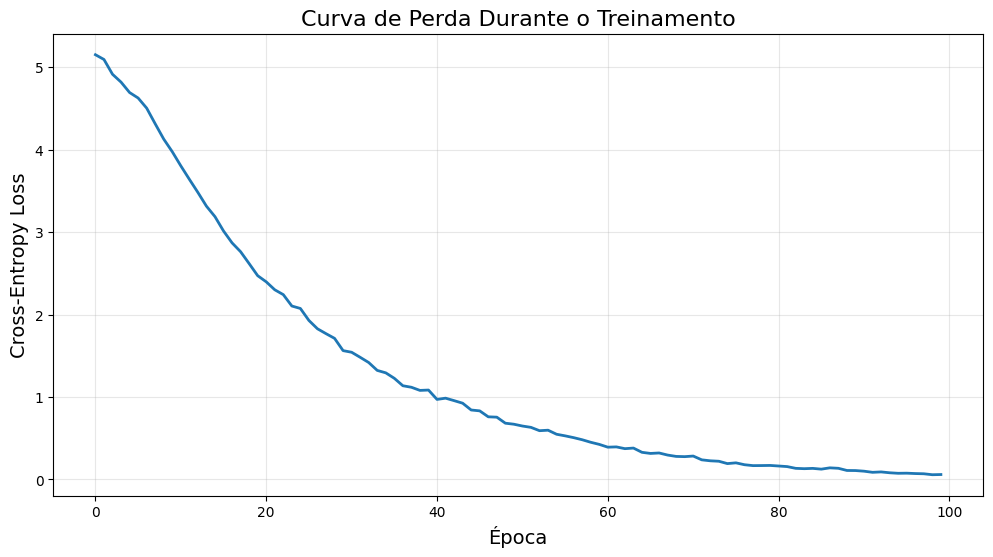

Perda inicial: 5.1521
Perda final: 0.0597
Redução: 98.8%


In [14]:
# Visualizar curva de perda
plt.figure(figsize=(12, 6))
plt.plot(training_losses, linewidth=2)
plt.title('Curva de Perda Durante o Treinamento', fontsize=16)
plt.xlabel('Época', fontsize=14)
plt.ylabel('Cross-Entropy Loss', fontsize=14)
plt.grid(True, alpha=0.3)
plt.show()

print(f"Perda inicial: {training_losses[0]:.4f}")
print(f"Perda final: {training_losses[-1]:.4f}")
print(f"Redução: {((training_losses[0] - training_losses[-1]) / training_losses[0] * 100):.1f}%")

## Geração Autorregressiva de Texto

Agora implementaremos a **geração autorregressiva**, onde o modelo gera texto palavra por palavra, usando suas próprias predições anteriores como entrada para as próximas predições.

### Processo de Geração

1. Começamos com uma sequência *seed* (semente)
2. O modelo prediz a próxima palavra mais provável
3. Adicionamos essa palavra à sequência
4. Repetimos o processo usando a nova sequência como entrada

### Estratégias de Amostragem

- **Greedy**: Sempre escolher a palavra mais provável
- **Random Sampling**: Amostrar aleatoriamente da distribuição de probabilidade
- **Temperature Sampling**: Controlar a "criatividade" com um parâmetro de temperatura

In [15]:
def generate_text(model, seed_text, max_length=50, temperature=1.0, device='cpu'):
    """Gera texto usando o modelo treinado."""
    model.eval()
    
    # Tokenizar e codificar texto seed
    seed_tokens = preprocess_text(seed_text)
    if len(seed_tokens) == 0:
        seed_tokens = ['inteligencia']  # Fallback
    
    # Codificar tokens
    seed_indices = encode_tokens(seed_tokens, w2i)
    
    # Garantir que temos pelo menos seq_length tokens
    if len(seed_indices) < seq_length:
        start_idx = w2i['<START>']
        seed_indices = [start_idx] * (seq_length - len(seed_indices)) + seed_indices
    else:
        seed_indices = seed_indices[-seq_length:]
    
    generated_indices = seed_indices.copy()
    current_sequence = seed_indices.copy()
    
    with torch.no_grad():
        for _ in range(max_length):
            # Converter para tensor
            input_tensor = torch.LongTensor([current_sequence]).to(device)
            
            # Forward pass
            output, _ = model(input_tensor)
            
            # Pegar logits da última posição
            last_logits = output[0, -1, :]
            
            # Aplicar temperature
            if temperature != 1.0:
                last_logits = last_logits / temperature
            
            # Converter para probabilidades
            probabilities = F.softmax(last_logits, dim=0)
            
            # Amostrar próxima palavra
            if temperature == 0.0:  # Greedy
                next_token_idx = torch.argmax(probabilities).item()
            else:  # Sampling
                next_token_idx = torch.multinomial(probabilities, 1).item()
            
            # Parar se gerar token de fim
            if next_token_idx == w2i.get('<END>', -1):
                break
            
            # Adicionar nova palavra
            generated_indices.append(next_token_idx)
            
            # Atualizar sequência atual (janela deslizante)
            current_sequence = current_sequence[1:] + [next_token_idx]
    
    # Decodificar de volta para texto
    generated_words = []
    for idx in generated_indices:
        word = i2w.get(idx, '<UNK>')
        if word not in ['<START>', '<END>', '<UNK>']:
            generated_words.append(word)
    
    return ' '.join(generated_words)

In [16]:
# Testar geração com diferentes seeds e temperaturas
seeds = [
    "inteligencia artificial",
    "aprendizado de maquina",
    "redes neurais"
]

temperatures = [0.5, 1.0, 1.5]

for seed in seeds:
    print(f"Seed: '{seed}'")
    print("-" * 50)
    
    for temp in temperatures:
        generated_text = generate_text(model, seed, max_length=30, temperature=temp, device=device)
        print(f"Temperature {temp}: {generated_text}")
    
    print()

Seed: 'inteligencia artificial'
--------------------------------------------------
Temperature 0.5: inteligencia artificial dados aos maquinas originais originais melhorar texto autonomas e de os encontrar os o de maquina tarefas de o overfitting o o o os adicionando os os muito modelo os
Temperature 1.0: inteligencia artificial gerem texto capacita maquinas maquinas autonomas maquinas visual da da padroes mundo estruturas algoritmos de de de de sistemas em o sugerir para conteudo prevenir humana ativacao humana a a
Temperature 1.5: inteligencia artificial maquinas treinamento descendente dados texto tipos gerem regularizacao e de subcampo e robotica humana novos usuarios as o o maquina a os modelo visual da descobre os os o de

Seed: 'aprendizado de maquina'
--------------------------------------------------
Temperature 0.5: aprendizado de maquina gerem a computadores computadores computadores computadores computadores computadores aos aprender maquinas maquinas a e maquinas um e para

## Análise dos Embeddings Aprendidos

Vamos visualizar os embeddings de palavras que o modelo aprendeu durante o treinamento. Palavras semanticamente similares devem ter embeddings próximos no espaço vetorial.

In [17]:
import os

os.environ["LOKY_MAX_CPU_COUNT"] = str(os.cpu_count())

C:\Users\clezi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\joblib\externals\loky\backend\context.py:150: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] O sistema não pode encontrar o arquivo especificado
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\clezi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\joblib\externals\loky\backend\context.py", line 227, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.12_3.12.2800.0_x64__qbz5n2kfra8p0\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^

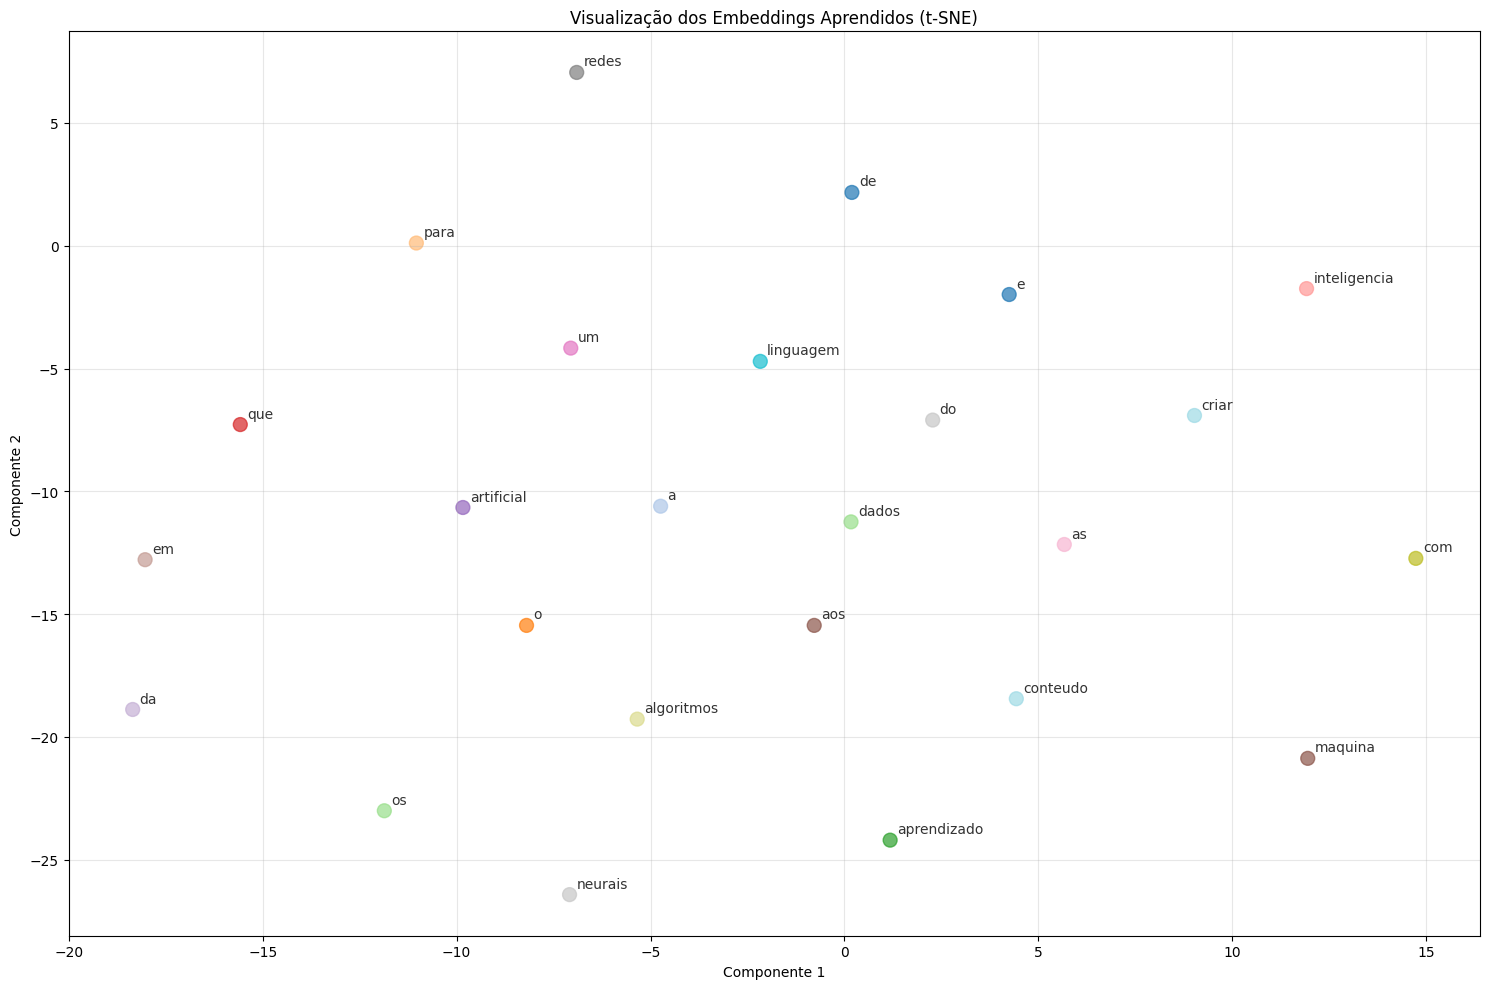

In [18]:
from sklearn.manifold import TSNE
from sklearn.metrics.pairwise import cosine_similarity

# Extrair embeddings
embeddings = model.embedding.weight.data.cpu().numpy()

# Selecionar palavras (pulando tokens especiais)
num_words = 25
words = vocab[3:num_words+3]
indices = [w2i[w] for w in words if w in w2i]

selected_embeddings = embeddings[indices]

# t-SNE
tsne = TSNE(
    n_components=2,
    random_state=42,
    perplexity=min(15, len(words) - 1)
)
embeddings_2d = tsne.fit_transform(selected_embeddings)

# Plot
plt.figure(figsize=(15, 10))
plt.scatter(
    embeddings_2d[:, 0],
    embeddings_2d[:, 1],
    alpha=0.7,
    s=100,
    c=range(len(words)),
    cmap="tab20"
)

for i, w in enumerate(words):
    plt.annotate(
        w,
        (embeddings_2d[i, 0], embeddings_2d[i, 1]),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=10,
        alpha=0.8
    )

plt.title("Visualização dos Embeddings Aprendidos (t-SNE)")
plt.xlabel("Componente 1")
plt.ylabel("Componente 2")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [19]:
print("PALAVRAS SIMILARES")
test_words = ['inteligencia', 'aprendizado', 'redes', 'dados']

for word in test_words:
    if word not in w2i:
        print(f"\nPalavra '{word}' não encontrada no vocabulário.")
        continue

    idx = w2i[word]
    word_emb = embeddings[idx].reshape(1, -1)

    sims = cosine_similarity(word_emb, embeddings)[0]
    similar_idxs = np.argsort(sims)[::-1][1:6]

    print(f"\nPalavras similares a '{word}':")
    for i in similar_idxs:
        if i in i2w:
            print(f"  {i2w[i]}: {sims[i]:.3f}")

PALAVRAS SIMILARES

Palavras similares a 'inteligencia':
  imagens: 0.325
  generativos: 0.240
  humana: 0.221
  visao: 0.204
  criar: 0.199

Palavras similares a 'aprendizado':
  capazes: 0.310
  integra: 0.272
  humano: 0.258
  rotulos: 0.218
  muito: 0.213

Palavras similares a 'redes':
  estruturas: 0.325
  descendente: 0.319
  se: 0.297
  interconectados: 0.252
  artificiais: 0.241

Palavras similares a 'dados':
  mecanica: 0.348
  ocultos: 0.297
  profundo: 0.268
  computadores: 0.267
  modelos: 0.245


## Exercícios

### Exercício 1: Hiperparâmetros

Modifique os hiperparâmetros (`embedding_dim`, `hidden_dim`, camadas, dropout...) do modelo LSTM e observe como afetam o desempenho. Para cada configuração, registre o tempo de treinamento e a qualidade subjetiva da geração de texto. Qual configuração oferece o melhor equilíbrio entre desempenho e eficiência?

In [20]:
import time
import itertools
import pandas as pd

# 1. Definindo os valores no Grid Search
param_grid = {
    'embedding_dim': [32, 64, 128],
    'hidden_dim': [64, 128, 256],
    'num_layers': [1, 2, 3],
    'dropout': [0.1, 0.3, 0.5]
}

# Criando todas as combinações possíveis
keys = param_grid.keys()
combinations = list(itertools.product(*param_grid.values()))

resultados = []
num_epochs_grid = 30 # Reduzido para testes mais rápidos

# 2. Preparando a chamada da função em um loop
for idx, values in enumerate(combinations):
    params = dict(zip(keys, values))
    
    # O PyTorch emite um aviso se aplicarmos dropout em LSTMs de apenas 1 camada
    if params['num_layers'] == 1:
        params['dropout'] = 0.0

    print(f"\nTestando Configuração {idx + 1}/{len(combinations)}: {params}")

    # Instanciar o modelo
    model_grid = LSTMLanguageModel(
        vocab_size=len(vocab),
        emb_dim=params['embedding_dim'],
        hid_dim=params['hidden_dim'],
        n_layers=params['num_layers'],
        dropout=params['dropout']
    ).to(device)

    criterion_grid = nn.CrossEntropyLoss()
    optimizer_grid = optim.Adam(model_grid.parameters(), lr=0.001)

    # Iniciar cronômetro
    start_time = time.time()

    # Treinamento
    final_loss = 0
    for epoch in range(num_epochs_grid):
        final_loss = train_epoch(model_grid, dataloader, criterion_grid, optimizer_grid, device)

    # Parar cronômetro
    end_time = time.time()
    tempo_execucao = end_time - start_time

    # Salvar resultados
    resultados.append({
        'embedding_dim': params['embedding_dim'],
        'hidden_dim': params['hidden_dim'],
        'num_layers': params['num_layers'],
        'dropout': params['dropout'],
        'final_loss': final_loss,
        'tempo_segundos': tempo_execucao
    })

# Converter para DataFrame para facilitar a visualização final
df_resultados = pd.DataFrame(resultados)
display(df_resultados.sort_values(by='final_loss'))


Testando Configuração 1/81: {'embedding_dim': 32, 'hidden_dim': 64, 'num_layers': 1, 'dropout': 0.0}

Testando Configuração 2/81: {'embedding_dim': 32, 'hidden_dim': 64, 'num_layers': 1, 'dropout': 0.0}

Testando Configuração 3/81: {'embedding_dim': 32, 'hidden_dim': 64, 'num_layers': 1, 'dropout': 0.0}

Testando Configuração 4/81: {'embedding_dim': 32, 'hidden_dim': 64, 'num_layers': 2, 'dropout': 0.1}

Testando Configuração 5/81: {'embedding_dim': 32, 'hidden_dim': 64, 'num_layers': 2, 'dropout': 0.3}

Testando Configuração 6/81: {'embedding_dim': 32, 'hidden_dim': 64, 'num_layers': 2, 'dropout': 0.5}

Testando Configuração 7/81: {'embedding_dim': 32, 'hidden_dim': 64, 'num_layers': 3, 'dropout': 0.1}

Testando Configuração 8/81: {'embedding_dim': 32, 'hidden_dim': 64, 'num_layers': 3, 'dropout': 0.3}

Testando Configuração 9/81: {'embedding_dim': 32, 'hidden_dim': 64, 'num_layers': 3, 'dropout': 0.5}

Testando Configuração 10/81: {'embedding_dim': 32, 'hidden_dim': 128, 'num_layers

,embedding_dim,hidden_dim,num_layers,dropout,final_loss,tempo_segundos
74,128,256,1,0.0,0.037136,1.795866
72,128,256,1,0.0,0.038236,1.853448
73,128,256,1,0.0,0.038933,1.824879
45,64,256,1,0.0,0.062832,1.743609
47,64,256,1,0.0,0.065626,1.659862
...,...,...,...,...,...,...
6,32,64,3,0.1,3.674238,1.966314
62,128,64,3,0.5,3.771706,1.904337
7,32,64,3,0.3,3.821675,1.887938
35,64,64,3,0.5,4.095878,1.878815


Ao considerar estritamente a combinação de hiperparâmetros que resultaram no menor valor retornado pela função de custo, pode-se afirmar que a combinação 74 obteve melhor score, seguida da 72, 73, 45 e 47. Todavia, ao se considerar exclusivamente o tempo em segundos, a ordem é alterada para as combinações de índices 29, 28, 2, 1 e 27.

In [21]:
display(df_resultados.sort_values(by='tempo_segundos'))

,embedding_dim,hidden_dim,num_layers,dropout,final_loss,tempo_segundos
29,64,64,1,0.0,1.557584,0.818883
28,64,64,1,0.0,1.566414,0.826343
2,32,64,1,0.0,2.230168,0.833036
1,32,64,1,0.0,2.232842,0.835463
27,64,64,1,0.0,1.663507,0.858171
...,...,...,...,...,...,...
53,64,256,3,0.5,2.351096,5.379461
80,128,256,3,0.5,1.595979,5.682640
78,128,256,3,0.1,0.872445,5.721997
52,64,256,3,0.3,1.206161,5.761154


### Exercício 2: Corpus

O corpus atual é relativamente pequeno. Adicione mais texto sobre IA em português (pode usar artigos da Wikipedia, livros em domínio público, etc.), implemente limpeza mais robusta (remoção de URLs, normalização de acentos, etc.). Teste com vocabulários maiores, use o corpus expandido e compare os resultados. Como o tamanho do corpus afeta a qualidade da geração?

In [26]:
import time
import itertools
import pandas as pd
import torch.nn as nn
import torch.optim as optim

def run_lstm_grid_search(param_grid, vocab_size, dataloader, device, num_epochs=30):
    """
    Executa um Grid Search para encontrar os melhores hiperparâmetros do LSTMLanguageModel.
    
    Args:
        param_grid (dict): Dicionário contendo os hiperparâmetros a serem combinados.
        vocab_size (int): Tamanho do vocabulário do corpus.
        dataloader (DataLoader): DataLoader com os dados de treinamento.
        device (torch.device): Dispositivo onde o modelo será processado ('cpu' ou 'cuda').
        num_epochs (int, opcional): Número de épocas de treinamento por configuração. Padrão é 30.
        
    Returns:
        pd.DataFrame: DataFrame ordenado pela menor perda (final_loss).
    """
    # Criando todas as combinações possíveis
    keys = param_grid.keys()
    combinations = list(itertools.product(*param_grid.values()))
    
    resultados = []
    
    # Preparando a chamada da função em um loop
    for idx, values in enumerate(combinations):
        params = dict(zip(keys, values))
        
        # O PyTorch emite um aviso se aplicarmos dropout em LSTMs de apenas 1 camada
        if params['num_layers'] == 1:
            params['dropout'] = 0.0

        print(f"\nTestando Configuração {idx + 1}/{len(combinations)}: {params}")

        # Instanciar o modelo
        model_grid = LSTMLanguageModel(
            vocab_size=vocab_size,
            emb_dim=params['embedding_dim'],
            hid_dim=params['hidden_dim'],
            n_layers=params['num_layers'],
            dropout=params['dropout']
        ).to(device)

        criterion_grid = nn.CrossEntropyLoss()
        optimizer_grid = optim.Adam(model_grid.parameters(), lr=0.001)

        # Iniciar cronômetro
        start_time = time.time()

        # Treinamento
        final_loss = 0
        for epoch in range(num_epochs):
            final_loss = train_epoch(model_grid, dataloader, criterion_grid, optimizer_grid, device)

        # Parar cronômetro
        end_time = time.time()
        tempo_execucao = end_time - start_time

        # Salvar resultados
        resultados.append({
            'embedding_dim': params['embedding_dim'],
            'hidden_dim': params['hidden_dim'],
            'num_layers': params['num_layers'],
            'dropout': params['dropout'],
            'final_loss': final_loss,
            'tempo_segundos': tempo_execucao
        })

    # Converter para DataFrame, ordenar pela melhor perda e resetar o índice
    df_resultados = pd.DataFrame(resultados).sort_values(by='final_loss').reset_index(drop=True)
    
    return df_resultados

In [24]:
corpus_text += """
A IA é um campo que abrange muitas disciplinas, como: ciência da computação, estatísticas, engenharia de hardware e de software, linguística, neurociência e, filosofia.
Os objetivos tradicionais da pesquisa em IA incluem raciocínio, representação de conhecimento, planejamento, aprendizagem, processamento de linguagem natural, percepção e suporte à robótica
O Simbolismo ou IA Simbólica, propõe a representação de conhecimento por meio da manipulação de símbolos
O Conexionismo ou IA Conexionista, se baseia em um modelo matemático inspirado no funcionamento dos neurônios
um agente inteligente é um sistema que percebe seu ambiente e toma atitudes que maximizam suas chances de sucesso
A inteligência artificial (IA) é uma tecnologia que permite que computadores e máquinas simulem o aprendizado, a compreensão, a resolução de problemas
em 2024, a maioria dos pesquisadores, profissionais de IA e a maioria das manchetes relacionadas a IA estão focados em avanços em IA generativa (IA gen)
Existem muitos tipos de técnicas ou algoritmos de aprendizado de máquina
Uma rede neural consiste em camadas interconectadas de nós (análogos aos neurônios) que trabalham juntas para processar e analisar dados complexos.
O deep learning é um subconjunto do aprendizado de máquina que usa redes neurais multicamadas, chamadas de redes neurais profundas, que simulam de forma mais próxima o complexo poder de tomada de decisão do cérebro humano.
As redes neurais profundas incluem uma camada de entrada, pelo menos três, mas geralmente centenas de camadas ocultas, e uma camada de saída, ao contrário das redes neurais usadas em modelos clássicos de aprendizado de máquina, que geralmente têm apenas uma ou duas camadas ocultas.
É adequado para processamento de linguagem natural (NLP), computer vision e outras tarefas que envolvem a identificação rápida e precisa de padrões e relacionamentos complexos em grandes quantidades de dados
Em um nível elevado, os modelos generativos codificam uma representação simplificada dos seus dados de treinamento
Em um nível elevado, os modelos generativos codificam uma representação simplificada dos seus dados de treinamento
Um agente de IA é um programa de IA autônomo. 
"""

In [25]:
tokens = preprocess_text(corpus_text)
vocab, w2i, i2w = build_vocabulary(tokens, 200)
encoded_tokens = encode_tokens(tokens, w2i)
seq_length = 10
sequences, targets = create_training_sequences(encoded_tokens, seq_length)
dataset = LanguageModelDataset(sequences, targets)
batch_size = 32
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

vocab_size = len(vocab)
embedding_dim = 64
hidden_dim = 128
num_layers = 2
dropout = 0.3

model = LSTMLanguageModel(vocab_size, embedding_dim, hidden_dim, num_layers, dropout)
model = model.to(device)

In [ ]:
# Definindo os valores no Grid Search
meu_param_grid = {
    'embedding_dim': [32, 64, 128],
    'hidden_dim': [64, 128, 256],
    'num_layers': [1, 2, 3],
    'dropout': [0.1, 0.3, 0.5]
}

# Executando a função
df_resultados_grid = run_lstm_grid_search(
    param_grid=meu_param_grid, 
    vocab_size=len(vocab), 
    dataloader=dataloader, 
    device=device, 
    num_epochs=30
)

# Exibindo os resultados
display(df_resultados_grid)


Testando Configuração 1/81: {'embedding_dim': 32, 'hidden_dim': 64, 'num_layers': 1, 'dropout': 0.0}

Testando Configuração 2/81: {'embedding_dim': 32, 'hidden_dim': 64, 'num_layers': 1, 'dropout': 0.0}

Testando Configuração 3/81: {'embedding_dim': 32, 'hidden_dim': 64, 'num_layers': 1, 'dropout': 0.0}

Testando Configuração 4/81: {'embedding_dim': 32, 'hidden_dim': 64, 'num_layers': 2, 'dropout': 0.1}

Testando Configuração 5/81: {'embedding_dim': 32, 'hidden_dim': 64, 'num_layers': 2, 'dropout': 0.3}

Testando Configuração 6/81: {'embedding_dim': 32, 'hidden_dim': 64, 'num_layers': 2, 'dropout': 0.5}

Testando Configuração 7/81: {'embedding_dim': 32, 'hidden_dim': 64, 'num_layers': 3, 'dropout': 0.1}

Testando Configuração 8/81: {'embedding_dim': 32, 'hidden_dim': 64, 'num_layers': 3, 'dropout': 0.3}

Testando Configuração 9/81: {'embedding_dim': 32, 'hidden_dim': 64, 'num_layers': 3, 'dropout': 0.5}

Testando Configuração 10/81: {'embedding_dim': 32, 'hidden_dim': 128, 'num_layers

,embedding_dim,hidden_dim,num_layers,dropout,final_loss,tempo_segundos
0,128,256,1,0.0,0.035063,3.819855
1,128,256,1,0.0,0.037809,3.761556
2,128,256,1,0.0,0.049784,4.211286
3,64,256,1,0.0,0.063326,3.453644
4,64,256,1,0.0,0.095134,3.497916
...,...,...,...,...,...,...
76,32,64,2,0.5,3.473009,3.070297
77,128,64,3,0.5,3.584599,4.044549
78,32,64,3,0.3,3.600265,3.922789
79,64,64,3,0.5,3.712542,3.794013


In [30]:
display(df_resultados_grid.sort_values(by='final_loss'))

,embedding_dim,hidden_dim,num_layers,dropout,final_loss,tempo_segundos
0,128,256,1,0.0,0.035063,3.819855
1,128,256,1,0.0,0.037809,3.761556
2,128,256,1,0.0,0.049784,4.211286
3,64,256,1,0.0,0.063326,3.453644
4,64,256,1,0.0,0.095134,3.497916
...,...,...,...,...,...,...
76,32,64,2,0.5,3.473009,3.070297
77,128,64,3,0.5,3.584599,4.044549
78,32,64,3,0.3,3.600265,3.922789
79,64,64,3,0.5,3.712542,3.794013


In [31]:
display(df_resultados_grid.sort_values(by='tempo_segundos'))

,embedding_dim,hidden_dim,num_layers,dropout,final_loss,tempo_segundos
35,64,64,1,0.0,1.754840,1.648777
32,64,64,1,0.0,1.610973,1.665773
34,64,64,1,0.0,1.663160,1.675211
44,32,64,1,0.0,2.207713,1.694492
42,32,64,1,0.0,2.162504,1.766259
...,...,...,...,...,...,...
40,64,256,3,0.1,1.991710,10.801652
43,64,256,3,0.3,2.190518,10.804280
48,128,256,3,0.5,2.373784,11.644978
38,128,256,3,0.3,1.880597,11.713823


### Exercício 3: Sampling

A função `generate_text` atual usa apenas temperature sampling. Implemente duas estratégias mais avançadas:

1. **Top-k Sampling**: Considere apenas as k palavras mais prováveis
2. **Top-p Sampling**: Considere o menor conjunto de palavras cuja probabilidade acumulada seja ≥ p

Compare a qualidade da geração entre as diferentes estratégias.

In [23]:
# Seu código aqui

In [32]:
import torch
import torch.nn.functional as F

def generate_text(model, seed_text, max_length=50, temperature=1.0, top_k=0, top_p=1.0, device='cpu'):
    """Gera texto usando o modelo treinado com suporte a Top-k e Top-p."""
    model.eval()
    
    # Tokenizar e codificar texto seed
    seed_tokens = preprocess_text(seed_text)
    if len(seed_tokens) == 0:
        seed_tokens = ['inteligencia']  # Fallback
    
    # Codificar tokens
    seed_indices = encode_tokens(seed_tokens, w2i)
    
    # Garantir que temos pelo menos seq_length tokens
    if len(seed_indices) < seq_length:
        start_idx = w2i['<START>']
        seed_indices = [start_idx] * (seq_length - len(seed_indices)) + seed_indices
    else:
        seed_indices = seed_indices[-seq_length:]
    
    generated_indices = seed_indices.copy()
    current_sequence = seed_indices.copy()
    
    with torch.no_grad():
        for _ in range(max_length):
            # Converter para tensor
            input_tensor = torch.LongTensor([current_sequence]).to(device)
            
            # Forward pass
            output, _ = model(input_tensor)
            
            # Pegar logits da última posição
            last_logits = output[0, -1, :]
            
            # 1. Aplicar temperature
            if temperature != 1.0 and temperature > 0.0:
                last_logits = last_logits / temperature
            
            # Se a temperatura for 0, fazemos um greedy search direto (ignorando top-k/p)
            if temperature == 0.0:
                next_token_idx = torch.argmax(last_logits).item()
            else:
                # 2. Aplicar Top-k
                if top_k > 0:
                    # Encontra o valor de corte para o k-ésimo maior logit
                    kth_value = torch.topk(last_logits, top_k)[0][-1]
                    # Zera (seta para -infinito) as probabilidades de tudo que estiver abaixo do corte
                    last_logits[last_logits < kth_value] = -float('Inf')
                
                # 3. Aplicar Top-p (Nucleus Sampling)
                if top_p < 1.0:
                    # Ordenar os logits em ordem decrescente
                    sorted_logits, sorted_indices = torch.sort(last_logits, descending=True)
                    # Calcular a probabilidade acumulada
                    cumulative_probs = torch.cumsum(F.softmax(sorted_logits, dim=-1), dim=-1)
                    
                    # Criar uma máscara para remover tokens que ultrapassam o limiar top_p
                    sorted_indices_to_remove = cumulative_probs > top_p
                    
                    # Deslocar a máscara para a direita para manter o primeiro token que cruza o limiar
                    sorted_indices_to_remove[1:] = sorted_indices_to_remove[:-1].clone()
                    sorted_indices_to_remove[0] = False
                    
                    # Recuperar os índices originais e aplicar o -infinito
                    indices_to_remove = sorted_indices[sorted_indices_to_remove]
                    last_logits[indices_to_remove] = -float('Inf')
                
                # 4. Converter para probabilidades finais e amostrar
                probabilities = F.softmax(last_logits, dim=-1)
                next_token_idx = torch.multinomial(probabilities, 1).item()
            
            # Parar se gerar token de fim
            if next_token_idx == w2i.get('<END>', -1):
                break
            
            # Adicionar nova palavra
            generated_indices.append(next_token_idx)
            
            # Atualizar sequência atual (janela deslizante)
            current_sequence = current_sequence[1:] + [next_token_idx]
    
    # Decodificar de volta para texto
    generated_words = []
    for idx in generated_indices:
        word = i2w.get(idx, '<UNK>')
        if word not in ['<START>', '<END>', '<UNK>']:
            generated_words.append(word)
    
    return ' '.join(generated_words)

In [33]:
# Testar geração com diferentes seeds e temperaturas
seeds = [
    "inteligencia artificial",
    "aprendizado de maquina",
    "redes neurais"
]

temperatures = [0.5, 1.0, 1.5]

for seed in seeds:
    print(f"Seed: '{seed}'")
    print("-" * 50)
    
    for temp in temperatures:
        generated_text = generate_text(model, seed, max_length=30, temperature=temp, device=device)
        print(f"Temperature {temp}: {generated_text}")
    
    print()

Seed: 'inteligencia artificial'
--------------------------------------------------
Temperature 0.5: inteligencia artificial novos camadas ia melhorar capacidade treino abrange permite muito mecanismos os interpretar incluem ia simplificada o humana sem padroes treinamento generativa sugerir audio analisar ativacao visao pode crucial representação subcampo
Temperature 1.0: inteligencia artificial identificar os avaliar revolucionaram um usado outros muitas capacidade melhorar processam é artificiais geralmente uma das usuarios partir outros ativacao aprendizado profundo atraves assemelham validacao do treinar processam
Temperature 1.5: inteligencia artificial camadas outros usado para sistemas um aprendizado treinamento atraves originais realizar analisar usado cerebro incluem interpretar profundo aprendem aprende visao abrange ajuda cruzada tarefas

Seed: 'aprendizado de maquina'
--------------------------------------------------
Temperature 0.5: aprendizado de maquina rotulos novos ci